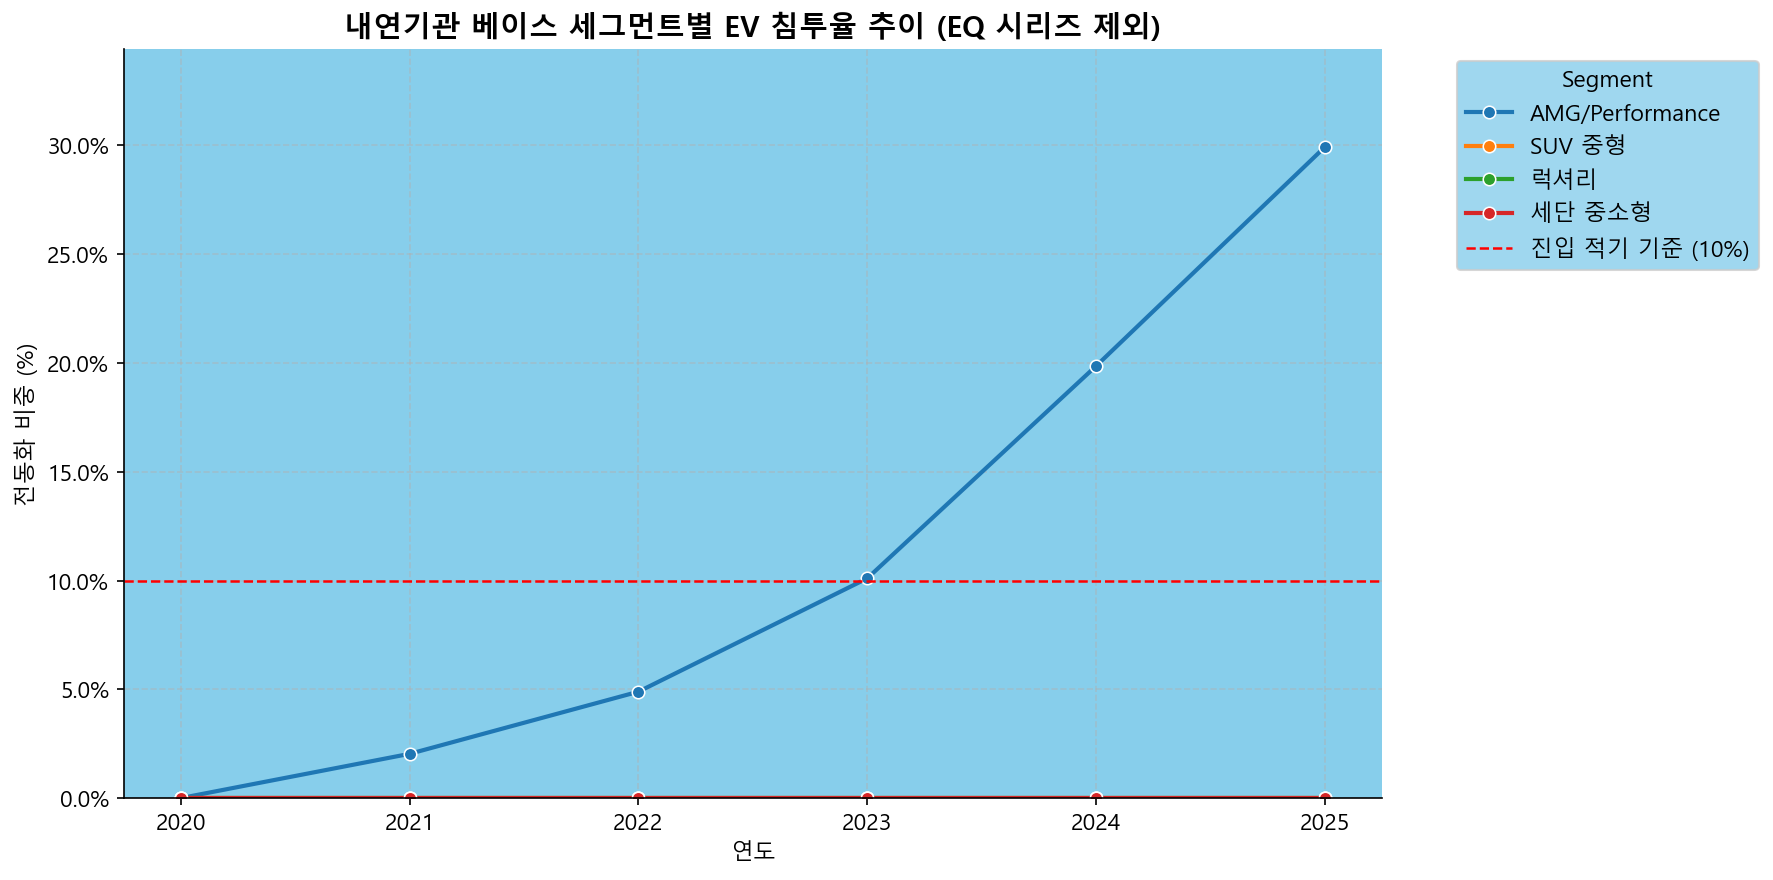

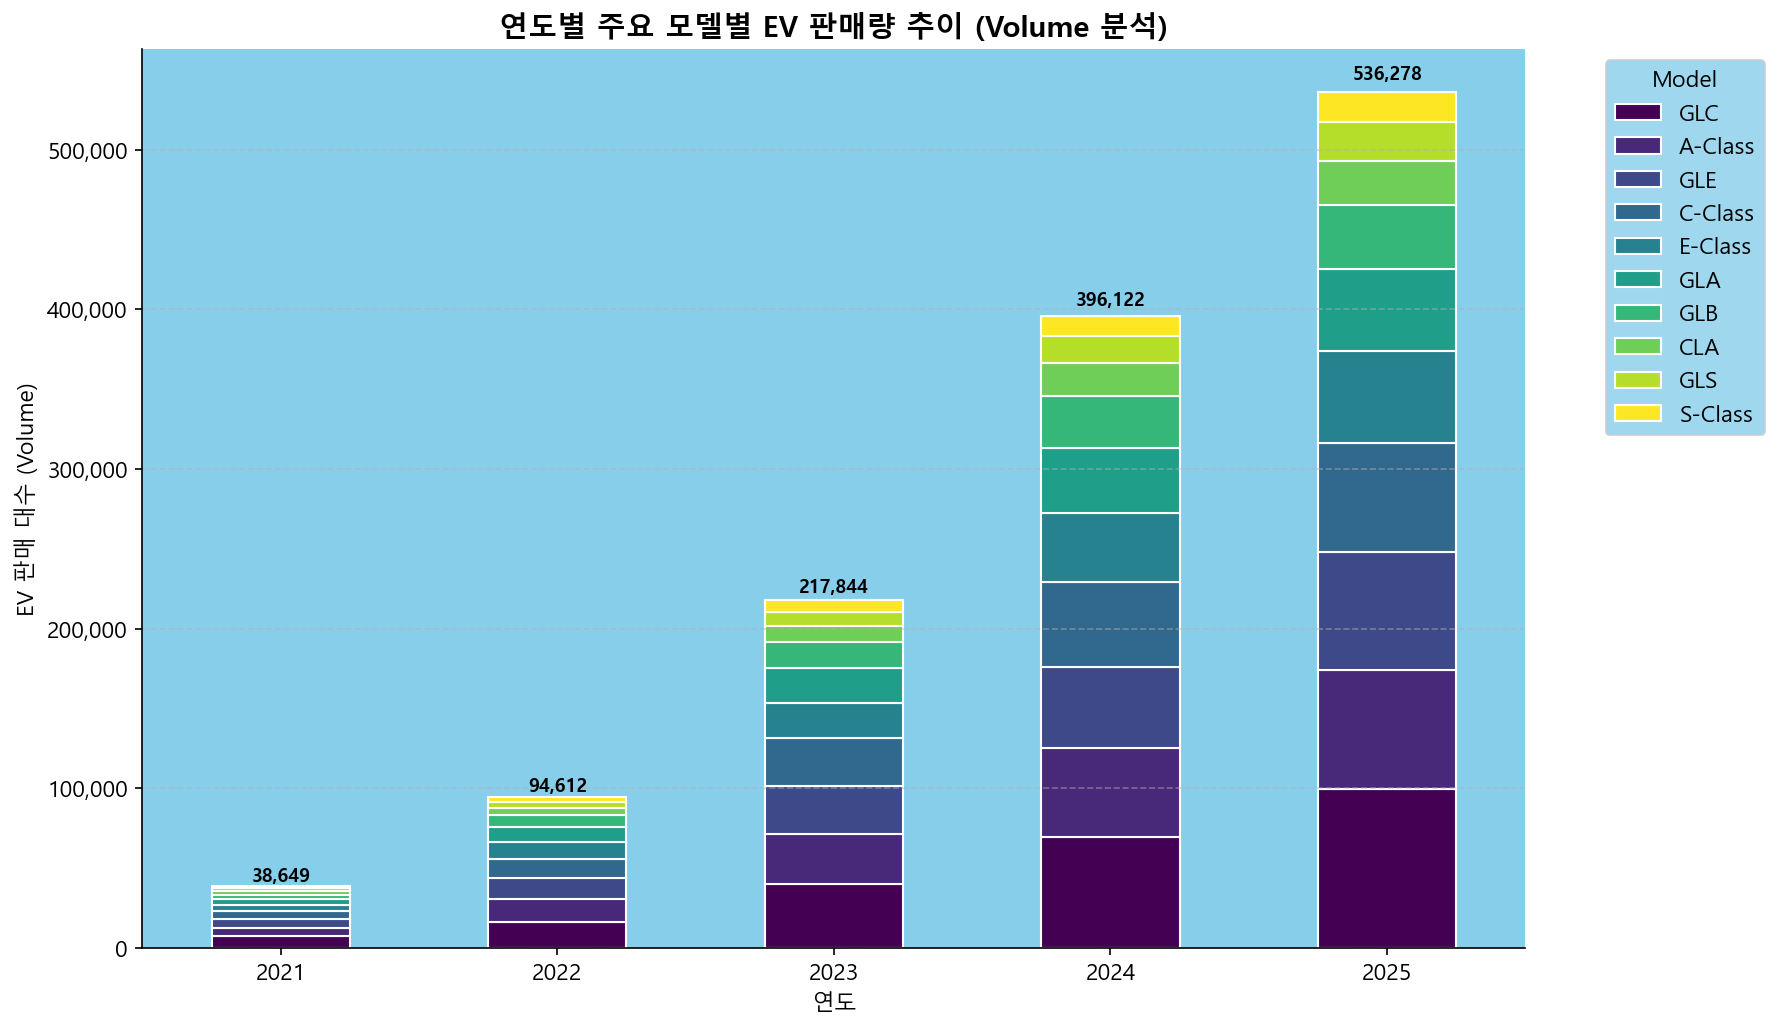


  2025년 상위 5개 모델 EV 판매량
  GLC               99,458 대
  A-Class           74,975 대
  GLE               73,878 대
  C-Class           68,098 대
  E-Class           57,274 대

  EV 총 판매량 CAGR (2021→2025)
  GLC               90.5% / yr
  A-Class           94.3% / yr
  GLE               91.8% / yr
  C-Class           94.8% / yr
  E-Class           96.2% / yr


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mticker 
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "skyblue",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# ── 데이터 로드 ───────────────────────────────────────────
df = pd.read_parquet("../data/processed/mercedes_processed.parquet")

SAVE_DIR = "../outputs/figures/"
plt.rcParams.update({"font.size": 11, "figure.dpi": 150})


# ════════════════════════════════════════════════════════
# CHART 05 │ 내연기관 베이스 세그먼트별 EV 침투율 추이
#            (EQ 시리즈 제외 — 정의상 100% EV이므로 왜곡 방지)
# ════════════════════════════════════════════════════════

# 연도 × 세그먼트별 집계
seg_analysis = (
    df.groupby(["Year", "Segment"])
    .agg(total_sales=("Is_EQ", "count"), ev_sales=("Is_EQ", "sum"))
    .reset_index()
)
seg_analysis["EV_Share"] = (
    seg_analysis["ev_sales"] / seg_analysis["total_sales"] * 100
)

# EQ 시리즈(EV) 제외
seg_filtered = seg_analysis[seg_analysis["Segment"] != "EQ 시리즈(EV)"]

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=seg_filtered,
    x="Year", y="EV_Share",
    hue="Segment", marker="o", linewidth=2, ax=ax
)

# 진입 적기 기준선 (10%) — Chart 11 전략 제언과 연결
ax.axhline(10, color="red", linestyle="--", linewidth=1.2,
           label="진입 적기 기준 (10%)")

ax.set_title("내연기관 베이스 세그먼트별 EV 침투율 추이 (EQ 시리즈 제외)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("전동화 비중 (%)")
ax.set_xlabel("연도")
ax.set_ylim(0, seg_filtered["EV_Share"].max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}05_segment_ev_penetration.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════
# CHART 06 │ 연도별 주요 모델별 EV 판매량 추이 (절댓값)
#            (EV 비중 % → 실제 판매 대수로 변경)
# ════════════════════════════════════════════════════════

# EV 데이터만 필터링
df_ev = df[df["Is_EQ"] == True]

# 연도 × 모델별 EV 판매량 집계
model_ev_vol = (
    df_ev.groupby(["Year", "Model"])
    .size()
    .unstack(fill_value=0)
)

# 판매량 상위 10개 모델만 사용 (가독성)
top10 = df_ev["Model"].value_counts().nlargest(10).index
vol_top10 = model_ev_vol[top10]

# 시각화
fig, ax = plt.subplots(figsize=(12, 7))

vol_top10.plot(
    kind="bar", stacked=True,
    colormap="viridis", edgecolor="white", ax=ax
)

# 막대 상단에 연도별 총합 표시
for i, (year, row) in enumerate(vol_top10.iterrows()):
    total = row.sum()
    ax.text(i, total + total * 0.01, f"{total:,.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("연도별 주요 모델별 EV 판매량 추이 (Volume 분석)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("EV 판매 대수 (Volume)")
ax.set_xlabel("연도")
ax.set_xticklabels(vol_top10.index, rotation=0)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)
ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}06_model_ev_volume_trend.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════
# 요약 출력 — README / 발표 수치 근거용
# ════════════════════════════════════════════════════════
latest_year = vol_top10.index.max()
first_year  = vol_top10.index.min()
n = latest_year - first_year

print(f"\n{'='*45}")
print(f"  {latest_year}년 상위 5개 모델 EV 판매량")
print(f"{'='*45}")
top5 = vol_top10.loc[latest_year].sort_values(ascending=False).head(5)
for model, vol in top5.items():
    print(f"  {model:<15} {vol:>8,} 대")

print(f"\n  EV 총 판매량 CAGR ({first_year}→{latest_year})")
print(f"{'='*45}")
for model in top5.index:
    v0   = vol_top10.loc[first_year, model]
    v1   = vol_top10.loc[latest_year, model]
    cagr = ((v1 / v0) ** (1 / n) - 1) * 100 if v0 > 0 else float("nan")
    print(f"  {model:<15} {cagr:>6.1f}% / yr")
print(f"{'='*45}")